## 003_Clustering

This cell clusters araucania based on a number of different input features. 

In [1]:
import warnings
warnings.filterwarnings("ignore")

import geopandas as gpd
import pandas as pd
from pathlib import Path
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.spatial.distance import cdist
from scipy.sparse import csr_matrix
from shapely.geometry import box
import matplotlib.pyplot as plt
from collections import defaultdict
from libpysal.weights import Rook

# ── Settings ──────────────────────────────────────────────────────────────────
IDENTIFIER       = "CHI_ARN"
DATA_OUT         = "../data_Araucania"
ATTRIBUTES_CSV   = f"{DATA_OUT}/{IDENTIFIER}_attributes.csv"
HOURLY_CF_SOLAR  = f"{DATA_OUT}/{IDENTIFIER}_solar_power_profile.csv"
HOURLY_CF_WIND   = f"{DATA_OUT}/{IDENTIFIER}_wind_power_profile.csv"
H2_DEMAND_CSV    = f"{DATA_OUT}/{IDENTIFIER}_H2_demand_MWh.csv"

CRS_METRIC        = "EPSG:32719"   # UTM Zone 19S — standard for Chile
n_clusters_target = 15
save_output       = True
floor_timeseries  = True           # zero tiny CF values (< 1e-4)

OUTPUT_DIR = f"../Cluster_Output_Araucania/Agglomerative/Agglomerative_k{n_clusters_target}/"
if save_output:
    Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
    Path(OUTPUT_DIR + "weighted_percentile_timeseries/").mkdir(parents=True, exist_ok=True)

print(f"Identifier:    {IDENTIFIER}")
print(f"n_clusters:    {n_clusters_target}")
print(f"Output dir:    {OUTPUT_DIR}")

Identifier:    CHI_ARN
n_clusters:    15
Output dir:    ../Cluster_Output_Araucania/Agglomerative/Agglomerative_k15/


In [2]:
def centroids_to_squares(df, lon_col='lon', lat_col='lat', dx=0.25):
    half = dx / 2.0
    df = df.copy()
    df['geometry'] = df.apply(
        lambda r: box(r[lon_col]-half, r[lat_col]-half, r[lon_col]+half, r[lat_col]+half), axis=1
    )
    return gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")

attrs = pd.read_csv(ATTRIBUTES_CSV)

if 'cell_id' not in attrs.columns:
    attrs['cell_id'] = attrs['lat'].apply(lambda x: f"{x:.2f}") + '_' + \
                       attrs['lon'].apply(lambda x: f"{x:.2f}")

gdf = centroids_to_squares(attrs)
gdf = gdf.set_index('cell_id')
cell_ids = gdf.index.to_numpy()
n = len(gdf)

print(f"Loaded {n} cells")
gdf[['lon', 'lat', 'wind_cf_mean', 'solar_cf_mean', 'avg_h2_demand_MWh',
     'available_land_area_km2', 'pc1', 'pc2']].head()

Loaded 63 cells


,lon,lat,wind_cf_mean,solar_cf_mean,avg_h2_demand_MWh,available_land_area_km2,pc1,pc2
cell_id,,,,,,,,
-39.50_-72.75,-72.75,-39.5,0.114337,0.158872,0.0,5.766301,17.522233,-54.131535
-39.50_-72.50,-72.50,-39.5,0.089602,0.154622,0.0,11.788670,-7.685006,-67.721773
-39.50_-72.25,-72.25,-39.5,0.056388,0.155186,0.0,24.192945,-34.580151,-67.126374
-39.50_-72.00,-72.00,-39.5,0.044329,0.160231,0.0,0.000000,-52.467309,-50.369209
-39.50_-71.75,-71.75,-39.5,0.070252,0.171108,0.0,0.000000,-60.887608,-4.256392


In [3]:
# Reproject to metric CRS
gdf = gdf.to_crs(CRS_METRIC)
coords = np.vstack([gdf.geometry.centroid.x, gdf.geometry.centroid.y]).T

# ── Attribute matrix ──────────────────────────────────────────────────────────
attr_cols = ['wind_cf_mean', 'solar_cf_mean', 'avg_h2_demand_MWh',
             'pc1', 'pc2', 'available_land_area_km2']

for col in attr_cols:
    if gdf[col].isna().any():
        median_val = gdf[col].median()
        print(f"Filling {gdf[col].isna().sum()} NaN in '{col}' with median: {median_val:.4f}")
        gdf[col] = gdf[col].fillna(median_val)

X_basic = gdf[attr_cols].values

X = np.hstack([
    np.log1p(X_basic[:, [2]]),   # log(1 + avg_h2_demand_MWh)
    X_basic[:, 1:2],              # solar_cf_mean
    X_basic[:, :1],               # wind_cf_mean
    X_basic[:, 3:6]               # pc1, pc2, available_land_area_km2
])

scaler = StandardScaler()
Z = scaler.fit_transform(X)

# ── Rook contiguity ───────────────────────────────────────────────────────────
A_rook_weights = Rook.from_dataframe(gdf.reset_index(), use_index=False)
A_rook = A_rook_weights.full()[0]

print(f"Feature matrix Z: {Z.shape}")
print(f"Rook adjacency: {int(A_rook.sum())} edges (avg {A_rook.sum()/n:.1f} per cell)")

Feature matrix Z: (63, 6)
Rook adjacency: 214 edges (avg 3.4 per cell)


In [4]:
def run_agglomerative(Z, A_contiguity, n_clusters):
    """Ward-linkage agglomerative clustering with Rook contiguity + singleton merging."""
    connectivity = csr_matrix(A_contiguity)

    for k_try in range(n_clusters, n_clusters + 10):
        agg = AgglomerativeClustering(
            n_clusters=k_try, linkage='ward', connectivity=connectivity
        )
        labels = agg.fit_predict(Z)

        # Merge singletons into nearest adjacent cluster
        changed = False
        while changed:
            changed = False
            unique, counts = np.unique(labels, return_counts=True)
            for cid in unique[counts == 1]:
                idx = np.where(labels == cid)[0][0]
                neighbors = np.where(A_contiguity[idx] > 0)[0]
                neighbor_labels = [labels[nb] for nb in neighbors if labels[nb] != cid]
                if neighbor_labels:
                    labels[idx] = neighbor_labels[0]
                    changed = True

        # Relabel consecutively
        for new, old in enumerate(np.unique(labels)):
            labels[labels == old] = new

        if len(np.unique(labels)) == n_clusters:
            print(f"Achieved {n_clusters} clusters (tried k={k_try})")
            return labels

    print(f"Warning: could not achieve exactly {n_clusters} clusters. Got {len(np.unique(labels))}.")
    return labels

cluster_labels = run_agglomerative(Z, A_rook, n_clusters_target)
gdf['cluster'] = cluster_labels

print(f"Cluster sizes:\n{pd.Series(cluster_labels).value_counts().sort_index()}")

Achieved 15 clusters (tried k=15)
Cluster sizes:
0      4
1     13
2      5
3      2
4      4
5      2
6      5
7      6
8      2
9      8
10     3
11     2
12     1
13     1
14     5
Name: count, dtype: int64


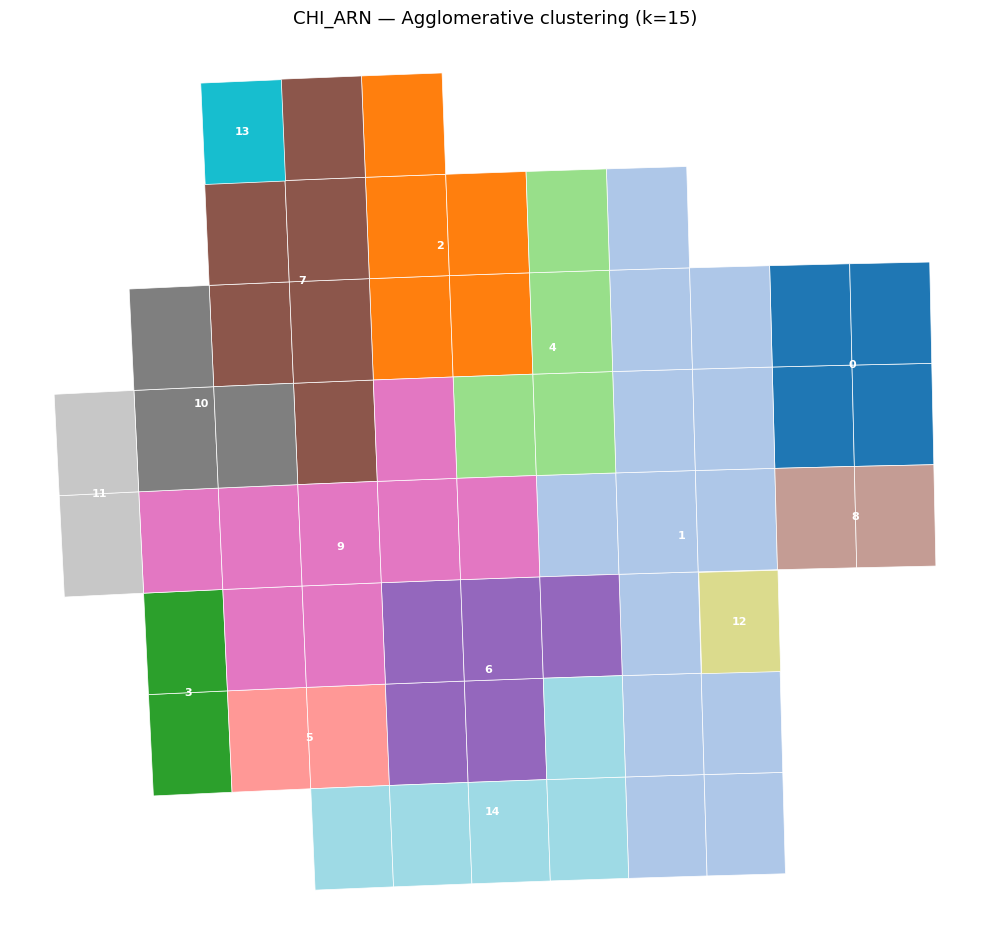

In [5]:
fig, ax = plt.subplots(figsize=(10, 12))

cmap = plt.cm.get_cmap('tab20', n_clusters_target)
for cluster_id in range(n_clusters_target):
    mask = gdf['cluster'] == cluster_id
    gdf[mask].plot(ax=ax, color=cmap(cluster_id), edgecolor='white', linewidth=0.5)
    # Label centroid
    centroid = gdf[mask].geometry.unary_union.centroid
    ax.annotate(str(cluster_id), xy=(centroid.x, centroid.y),
                ha='center', va='center', fontsize=8, fontweight='bold', color='white')

ax.set_title(f'{IDENTIFIER} — Agglomerative clustering (k={n_clusters_target})', fontsize=13)
ax.set_axis_off()
plt.tight_layout()
if save_output:
    plt.savefig(OUTPUT_DIR + f"clustering_k{n_clusters_target}.png", dpi=150, bbox_inches='tight')
plt.show()

In [6]:
df_cells = gdf.copy()

def choose_representative(cluster_df):
    """Cell whose centroid is closest to the geographic centroid of the cluster."""
    cx = cluster_df.geometry.centroid.x.mean()
    cy = cluster_df.geometry.centroid.y.mean()
    dists = np.sqrt((cluster_df.geometry.centroid.x - cx)**2 +
                    (cluster_df.geometry.centroid.y - cy)**2)
    return cluster_df.index[np.argmin(dists)]

cluster_reps = {}
for c, grp in df_cells.groupby('cluster'):
    cluster_reps[c] = choose_representative(grp)

# Collapse inter-cluster Rook edges
edge_buckets = defaultdict(list)
for i in range(n):
    for j in np.where(A_rook[i] > 0)[0]:
        ci, cj = cluster_labels[i], cluster_labels[j]
        if ci == cj:
            continue
        key = tuple(sorted((ci, cj)))
        edge_buckets[key].append((i, j))

reduced_links = []
for (ci, cj), edges in edge_buckets.items():
    rep_i = cluster_reps[ci]
    rep_j = cluster_reps[cj]
    coord_i = np.array([df_cells.loc[rep_i].geometry.centroid.x,
                        df_cells.loc[rep_i].geometry.centroid.y])
    coord_j = np.array([df_cells.loc[rep_j].geometry.centroid.x,
                        df_cells.loc[rep_j].geometry.centroid.y])
    distance_km = np.linalg.norm(coord_i - coord_j) / 1000
    reduced_links.append({
        'cluster_a':       ci,
        'cluster_b':       cj,
        'rep_cell_a':      rep_i,
        'rep_cell_b':      rep_j,
        'n_cross_edges':   len(edges),
        'distance_km':     distance_km,
    })

reduced_links_df = pd.DataFrame(reduced_links)
if reduced_links_df.empty:
    reduced_links_df = pd.DataFrame(columns=[
        'cluster_a', 'cluster_b', 'rep_cell_a', 'rep_cell_b', 'n_cross_edges', 'distance_km'
    ])

print(f"Representative nodes: {len(cluster_reps)}")
print(f"Inter-cluster links:  {len(reduced_links_df)}")
reduced_links_df.head()

Representative nodes: 15
Inter-cluster links:  25


,cluster_a,cluster_b,rep_cell_a,rep_cell_b,n_cross_edges,distance_km
0,5,14,-39.25_-73.00,-39.50_-72.25,2,70.390031
1,6,14,-39.00_-72.25,-39.50_-72.25,8,55.541572
2,1,14,-38.75_-71.75,-39.50_-72.25,4,93.859806
3,3,5,-39.25_-73.25,-39.25_-73.00,2,21.605239
4,5,9,-39.25_-73.00,-38.75_-72.75,4,59.641485


In [7]:
hourly_solar = pd.read_csv(HOURLY_CF_SOLAR, index_col=0, parse_dates=True)
hourly_wind  = pd.read_csv(HOURLY_CF_WIND,  index_col=0, parse_dates=True)
h2_df        = pd.read_csv(H2_DEMAND_CSV,   index_col=0, parse_dates=True)

# Build location string matching profile column names
df_cells = df_cells.to_crs("EPSG:4326")   # back to WGS84 for lat/lon labels
df_cells['location'] = (df_cells['lat'].apply(lambda x: f"{x:.2f}") + '_' +
                        df_cells['lon'].apply(lambda x: f"{x:.2f}"))

cluster_wind_weighted  = pd.DataFrame(index=hourly_wind.index)
cluster_solar_weighted = pd.DataFrame(index=hourly_solar.index)
cluster_h2_demand      = pd.DataFrame(index=h2_df.index)

for cluster_id in sorted(df_cells['cluster'].unique()):
    grp = df_cells[df_cells['cluster'] == cluster_id].copy()
    col_name = f"cluster_{int(cluster_id)}"

    # ── Weighted wind & solar (by available_land_area_km2) ────────────────
    wind_locs  = [loc for loc in grp['location'] if loc in hourly_wind.columns]
    solar_locs = [loc for loc in grp['location'] if loc in hourly_solar.columns]

    if wind_locs:
        w_area = grp.set_index('location')['available_land_area_km2'].reindex(wind_locs).values
        w_area = w_area / w_area.sum() if w_area.sum() > 0 else np.ones(len(wind_locs)) / len(wind_locs)
        cluster_wind_weighted[col_name] = np.average(
            hourly_wind[wind_locs].values, axis=1, weights=w_area)
    else:
        cluster_wind_weighted[col_name] = 0.0

    if solar_locs:
        s_area = grp.set_index('location')['available_land_area_km2'].reindex(solar_locs).values
        s_area = s_area / s_area.sum() if s_area.sum() > 0 else np.ones(len(solar_locs)) / len(solar_locs)
        cluster_solar_weighted[col_name] = np.average(
            hourly_solar[solar_locs].values, axis=1, weights=s_area)
    else:
        cluster_solar_weighted[col_name] = 0.0

    # ── H2 demand: sum cell profiles across cluster ────────────────────────
    h2_locs = [loc for loc in grp['location'] if loc in h2_df.columns]
    cluster_h2_demand[col_name] = -1*h2_df[h2_locs].sum(axis=1) if h2_locs else 0.0

# Floor tiny CF values
if floor_timeseries:
    cf_floor = 1e-4
    cluster_wind_weighted  = cluster_wind_weighted.where(cluster_wind_weighted >= cf_floor, 0.0)
    cluster_solar_weighted = cluster_solar_weighted.where(cluster_solar_weighted >= cf_floor, 0.0)

print(f"Wind profile shape:   {cluster_wind_weighted.shape}")
print(f"Solar profile shape:  {cluster_solar_weighted.shape}")
print(f"H2 demand shape:      {cluster_h2_demand.shape}")

Wind profile shape:   (8760, 15)
Solar profile shape:  (8760, 15)
H2 demand shape:      (8760, 15)


In [8]:
# Reproject back to metric for representative coordinates
df_cells_metric = df_cells.to_crs(CRS_METRIC)

cluster_metadata_list = []
for cluster_id in sorted(df_cells['cluster'].unique()):
    cluster_cells    = df_cells[df_cells['cluster'] == cluster_id]
    rep_cell         = cluster_reps[cluster_id]
    rep_row          = df_cells.loc[rep_cell]
    avg_h2_per_hour  = cluster_h2_demand[f"cluster_{int(cluster_id)}"].mean()

    cluster_metadata_list.append({
        'cluster_id':              int(cluster_id),
        'lat':                     rep_row['lat'],
        'lon':                     rep_row['lon'],
        'n_cells':                 len(cluster_cells),
        'land_area_km2':           cluster_cells['area_km2'].sum(),
        'available_land_area_km2': cluster_cells['available_land_area_km2'].sum(),
        'avg_h2_demand_MWh':       avg_h2_per_hour,
    })

cluster_metadata_df = (pd.DataFrame(cluster_metadata_list)
                        .sort_values('cluster_id')
                        .reset_index(drop=True))

print(cluster_metadata_df)

    cluster_id    lat    lon  n_cells  land_area_km2  available_land_area_km2  \
0            0 -38.50 -71.00        4    1997.703473                 0.000000   
1            1 -38.75 -71.75       13    6482.112989                67.629164   
2            2 -38.00 -72.50        5    2753.963463               213.732508   
3            3 -39.25 -73.25        2     726.718283                92.234069   
4            4 -38.25 -72.00        4    2081.077966               188.361974   
5            5 -39.25 -73.00        2    1056.399432                26.095889   
6            6 -39.00 -72.25        5    3001.079848               405.438507   
7            7 -38.25 -72.75        6    3591.673739               271.674563   
8            8 -38.75 -71.25        2     809.618290               199.017059   
9            9 -38.75 -72.75        8    4823.004792               680.096708   
10          10 -38.50 -73.25        3    1374.652918                27.870789   
11          11 -38.50 -73.50

In [9]:
if save_output:
    weighted_dir = OUTPUT_DIR + "weighted_percentile_timeseries/"

    # Timeseries
    cluster_wind_weighted.to_csv(weighted_dir  + "cluster_wind_profiles_weighted.csv")
    cluster_solar_weighted.to_csv(weighted_dir + "cluster_solar_profiles_weighted.csv")

    # H2 demand
    cluster_h2_demand.to_csv(OUTPUT_DIR + "cluster_h2_demand_profiles.csv")

    # Metadata
    cluster_metadata_df.to_csv(OUTPUT_DIR + "cluster_metadata.csv", index=False)

    # Network
    reduced_links_df.to_csv(OUTPUT_DIR + "reduced_links.csv", index=False)
    pd.Series(cluster_reps, name='rep_cell').to_csv(OUTPUT_DIR + "cluster_reps.csv", header=True)
    pd.Series(cluster_labels, index=cell_ids, name='cluster').to_csv(
        OUTPUT_DIR + "cell_to_cluster_mapping.csv")

    # Geodata
    df_cells.to_crs("EPSG:4326").to_file(OUTPUT_DIR + "clusters_geodata.geojson", driver="GeoJSON")

    # Summary
    summary = {
        'clustering_method':          'Agglomerative',
        'n_clusters':                  len(cluster_metadata_df),
        'n_cells':                     len(df_cells),
        'n_interconnections':          len(reduced_links_df),
        'total_land_area_km2':         float(cluster_metadata_df['land_area_km2'].sum()),
        'total_available_land_km2':    float(cluster_metadata_df['available_land_area_km2'].sum()),
        'total_avg_h2_demand_MWh':     float(cluster_metadata_df['avg_h2_demand_MWh'].sum()),
    }
    pd.DataFrame([summary]).to_csv(OUTPUT_DIR + "summary_statistics.csv", index=False)

    print(f"All outputs saved to: {OUTPUT_DIR}")
    print(f"  - cluster_metadata.csv")
    print(f"  - weighted_percentile_timeseries/cluster_wind_profiles_weighted.csv")
    print(f"  - weighted_percentile_timeseries/cluster_solar_profiles_weighted.csv")
    print(f"  - cluster_h2_demand_profiles.csv")
    print(f"  - reduced_links.csv, cluster_reps.csv, cell_to_cluster_mapping.csv")
    print(f"  - clusters_geodata.geojson, summary_statistics.csv")

All outputs saved to: ../Cluster_Output_Araucania/Agglomerative/Agglomerative_k15/
  - cluster_metadata.csv
  - weighted_percentile_timeseries/cluster_wind_profiles_weighted.csv
  - weighted_percentile_timeseries/cluster_solar_profiles_weighted.csv
  - cluster_h2_demand_profiles.csv
  - reduced_links.csv, cluster_reps.csv, cell_to_cluster_mapping.csv
  - clusters_geodata.geojson, summary_statistics.csv


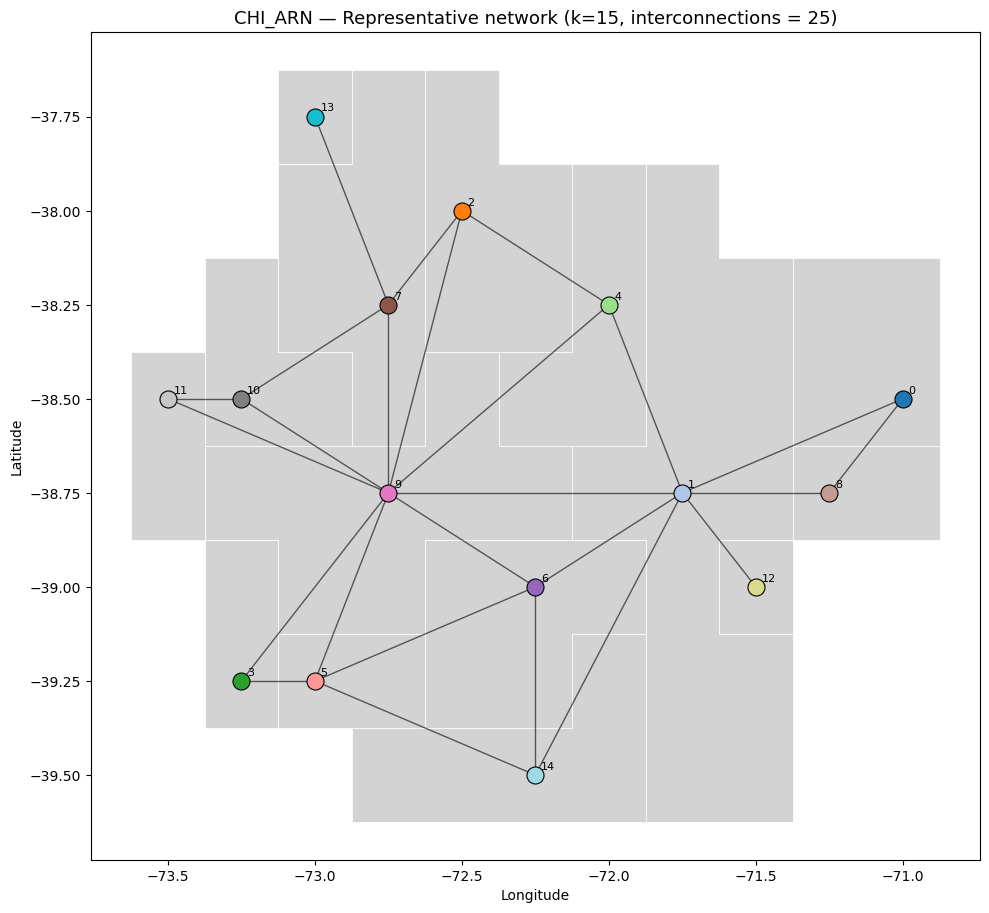

In [10]:
fig, ax = plt.subplots(figsize=(10, 12))

# Draw cluster polygons (dissolved)
df_cells_wgs = df_cells.to_crs("EPSG:4326")
df_cells_wgs.dissolve(by='cluster').plot(ax=ax, facecolor='lightgrey', edgecolor='white', linewidth=0.5)

# Draw inter-cluster links
for _, link in reduced_links_df.iterrows():
    rep_a = df_cells_wgs.loc[link['rep_cell_a']]
    rep_b = df_cells_wgs.loc[link['rep_cell_b']]
    ax.plot([rep_a['lon'], rep_b['lon']], [rep_a['lat'], rep_b['lat']],
            'k-', linewidth=1.0, alpha=0.6, transform=plt.gca().transData)

# Draw representative nodes
cmap = plt.cm.get_cmap('tab20', n_clusters_target)
for cluster_id, rep_cell in cluster_reps.items():
    rep = df_cells_wgs.loc[rep_cell]
    ax.scatter(rep['lon'], rep['lat'], s=150, color=cmap(cluster_id),
               edgecolors='black', linewidths=0.8, zorder=5)
    ax.annotate(str(cluster_id), xy=(rep['lon'], rep['lat']),
                xytext=(4, 4), textcoords='offset points', fontsize=8)

ax.set_title(f'{IDENTIFIER} — Representative network (k={n_clusters_target}, interconnections = {len(reduced_links_df)})', fontsize=13)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
if save_output:
    plt.savefig(OUTPUT_DIR + "representative_network.png", dpi=150, bbox_inches='tight')
plt.show()